In [1]:
# Cell 1 — imports
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import random_statevector, partial_trace, state_fidelity, Statevector
from qiskit.visualization import plot_bloch_multivector, plot_histogram

sim = AerSimulator(method='statevector')

psi: [ 0.706+0.684j -0.12 -0.139j]


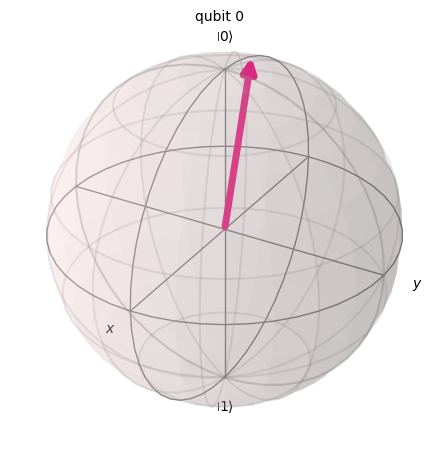

In [2]:
# Cell 2 — a fresh random message state, and look at it
psi = random_statevector(2)
print("psi:", np.round(psi.data, 3))
plot_bloch_multivector(psi)        # the arrow we're about to teleport

In [3]:
# Cell 3 — modular helpers (same roles as the reference, modern gates)
def bell_pair(qc, a, b):
    qc.h(a); qc.cx(a, b)

def alice_gates(qc, msg, a):
    qc.cx(msg, a); qc.h(msg)

def measure_and_send(qc, a, b, crz, crx):
    # qc.barrier()
    qc.measure(a, crz)   # -> crz
    qc.measure(b, crx)   # -> crx

def bob_gates(qc, qubit, crz, crx):
    with qc.if_test((crx, 1)):   
        qc.x(qubit)
    with qc.if_test((crz, 1)):   
        qc.z(qubit)

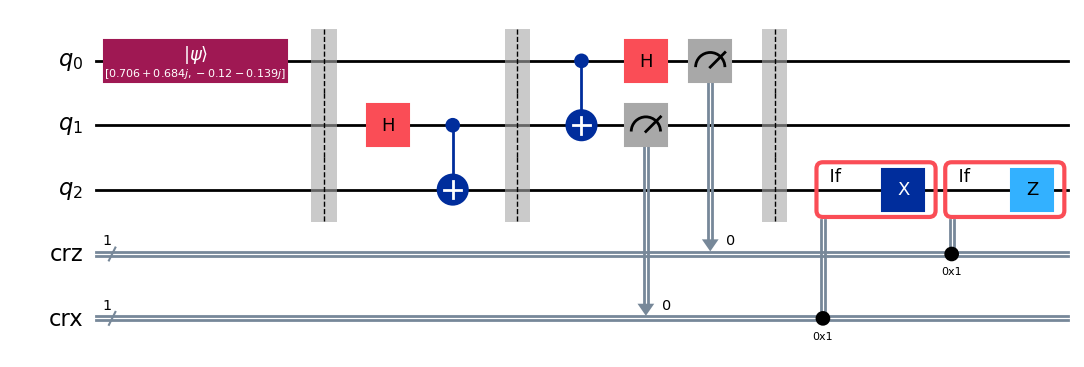

In [4]:
# Cell 4 — assemble the circuit
q   = QuantumRegister(3, 'q')
crz = ClassicalRegister(1, 'crz')
crx = ClassicalRegister(1, 'crx')
qc  = QuantumCircuit(q, crz, crx)

qc.initialize(psi.data, 0); qc.barrier()   # put psi on q0
bell_pair(qc, 1, 2);        qc.barrier()    # entangle q1,q2 (q2 is Bob's)
alice_gates(qc, 0, 1)
measure_and_send(qc, 0, 1, crz, crx);  qc.barrier()
bob_gates(qc, 2, crz, crx)

qc.draw('mpl',filename='teleportation_circuit.png')

fidelity(Bob, psi): 1.0


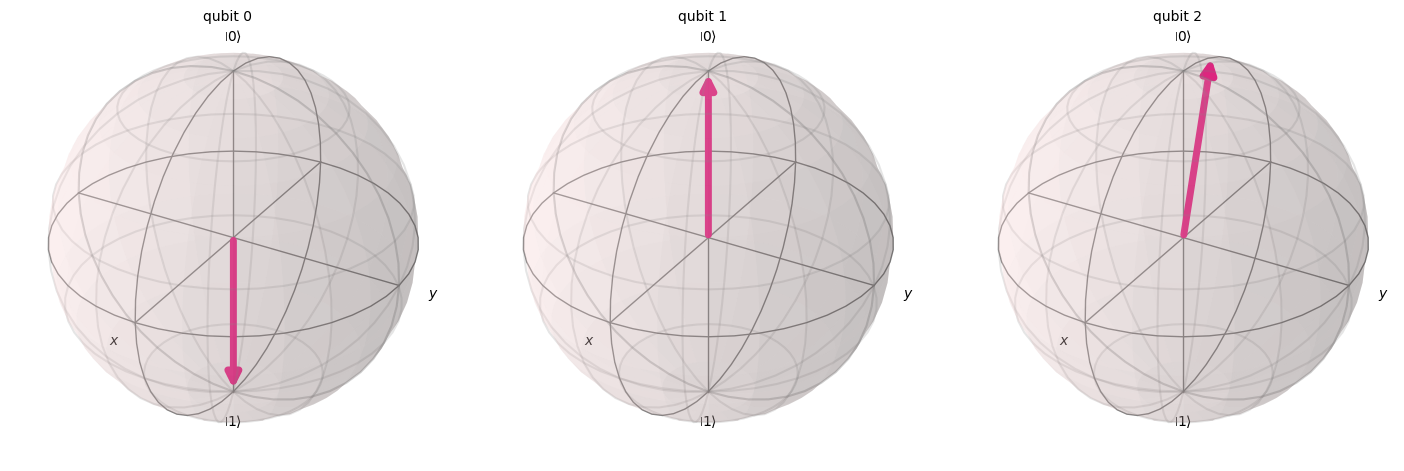

In [5]:
# Cell 5 — confirm Bob ended up holding psi (the visual + the number)
sv_circ = qc.copy()
sv_circ.save_statevector()
sv = sim.run(transpile(sv_circ, sim)).result().get_statevector()

rho_bob = partial_trace(sv, [0, 1])                 # keep only Bob's qubit
fid = state_fidelity(rho_bob, Statevector(psi.data))
print("fidelity(Bob, psi):", round(fid, 6))         # -> 1.0
plot_bloch_multivector(sv)                           # q2's arrow == Cell 2's arrow

{'1 1': 2015, '0 1': 2123, '1 0': 2015, '0 0': 2039}


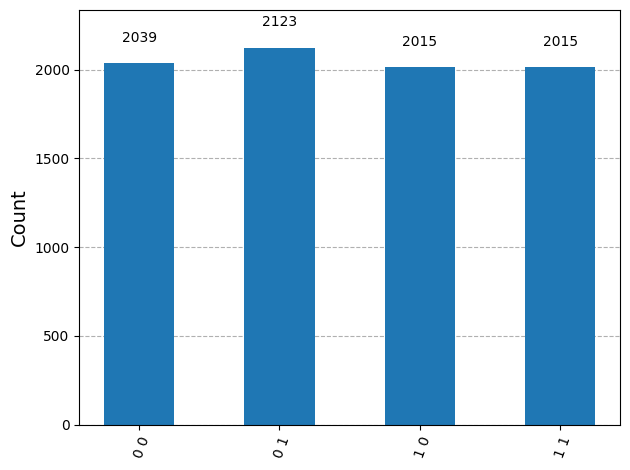

In [6]:
# Cell 6 — honest check: Alice's two bits are pure noise on their own
counts = sim.run(transpile(qc, sim), shots=8192).result().get_counts()
print(counts)            # ~25% each: 00, 01, 10, 11
plot_histogram(counts)